In [1]:
import os 
os.environ["OMP_NUM_THREADS"] = "2"

In [2]:
# Level 1 Task 1- Data Claening and PreProcessing

In [3]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

# Load the dataset
# The raw file has no header row and is whitespace-separated, not comma-separated
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
                'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

df = pd.read_csv('house Prediction Data Set.csv', sep=r'\s+', names=column_names)

print("BEFORE CLEANING")
print(f"Shape: {df.shape}")
df.head()

BEFORE CLEANING
Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
# Initial inspection
print("Data types:")
print(df.dtypes)
print()
print("Summary statistics:")
df.describe()

Data types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Summary statistics:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [5]:
# Identify and handle missing values
print("Missing values BEFORE handling:")
print(df.isnull().sum())
missing_total_before = df.isnull().sum().sum()
print(f"\nTotal missing values: {missing_total_before}")

if missing_total_before > 0:
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"Filled missing values in '{col}' with median: {median_val:.2f}")
else:
    print("No missing values found in this dataset - no imputation needed.")

print("\nMissing values AFTER handling:")
print(df.isnull().sum().sum())

Missing values BEFORE handling:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Total missing values: 0
No missing values found in this dataset - no imputation needed.

Missing values AFTER handling:
0


In [6]:
# Remove duplicate rows
rows_before = df.shape[0]
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

df = df.drop_duplicates()

rows_after = df.shape[0]
print(f"Rows BEFORE removing duplicates: {rows_before}")
print(f"Rows AFTER removing duplicates: {rows_after}")

Duplicate rows found: 0
Rows BEFORE removing duplicates: 506
Rows AFTER removing duplicates: 506


In [7]:
# Standardize inconsistent data formats
# CHAS is stored as an integer (0/1) but is really a categorical flag
print("CHAS dtype BEFORE:", df['CHAS'].dtype)
print("CHAS unique values BEFORE:", df['CHAS'].unique())

df['CHAS'] = df['CHAS'].map({0: 'No', 1: 'Yes'}).astype('category')

print("\nCHAS dtype AFTER:", df['CHAS'].dtype)
print("CHAS unique values AFTER:", df['CHAS'].unique())

print("\nAll dtypes after standardization:")
print(df.dtypes)


CHAS dtype BEFORE: int64
CHAS unique values BEFORE: [0 1]

CHAS dtype AFTER: category
CHAS unique values AFTER: ['No', 'Yes']
Categories (2, object): ['No', 'Yes']

All dtypes after standardization:
CRIM        float64
ZN          float64
INDUS       float64
CHAS       category
NOX         float64
RM          float64
AGE         float64
DIS         float64
RAD           int64
TAX         float64
PTRATIO     float64
B           float64
LSTAT       float64
MEDV        float64
dtype: object


In [8]:
# Save the cleaned dataset
df.to_csv('house_data_cleaned.csv', index=False)
print("Cleaned dataset saved as 'house_data_cleaned.csv'")
print(f"\nFinal shape: {df.shape}")
df.head()

Cleaned dataset saved as 'house_data_cleaned.csv'

Final shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,No,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,No,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,No,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,No,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,No,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [9]:
# Level 1 Task 2- Explanatory Data Analysis

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [11]:
# Summary statistics
numeric_df = df.select_dtypes(include=[np.number])

summary = pd.DataFrame({
    'mean': numeric_df.mean(),
    'median': numeric_df.median(),
    'mode': numeric_df.mode().iloc[0],
    'std': numeric_df.std()
})

print("Summary statistics (mean, median, mode, std dev):")
summary.round(2)

numeric_df.describe().round(2)

Summary statistics (mean, median, mode, std dev):


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


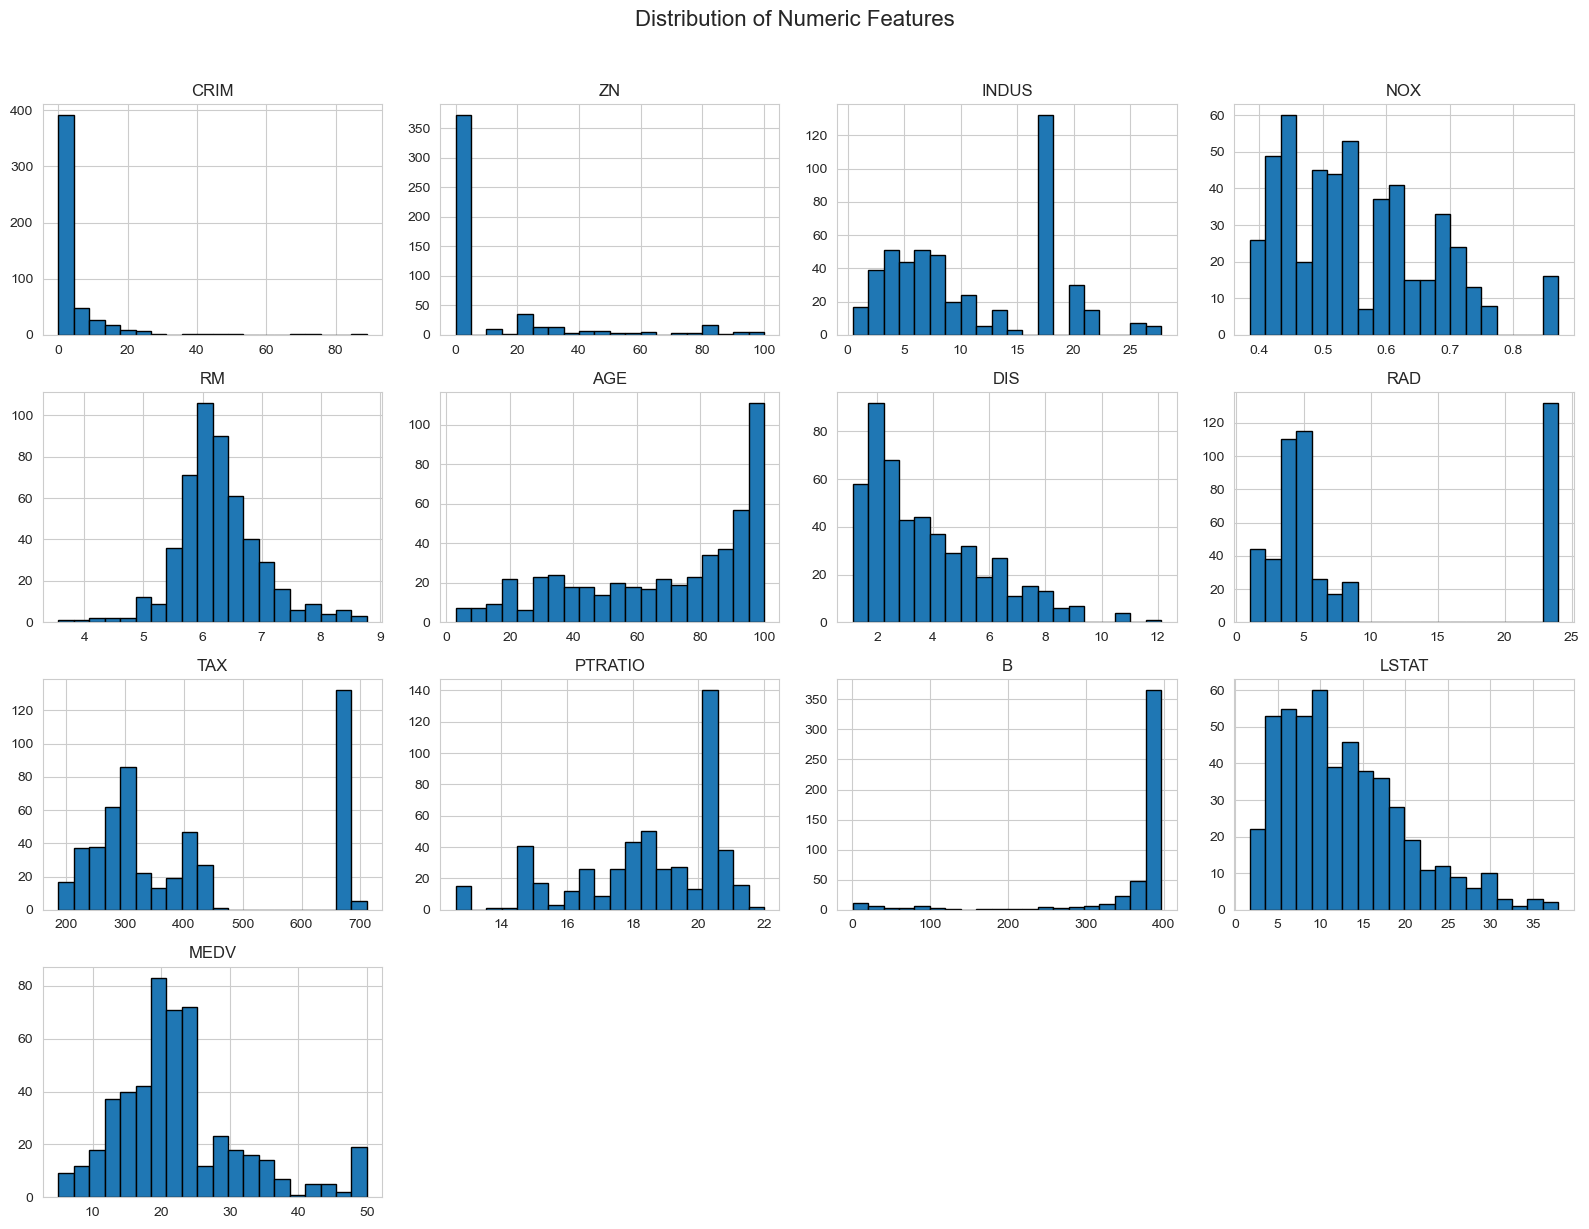

In [12]:
# Histograms - data distributions
numeric_df.hist(figsize=(16, 12), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

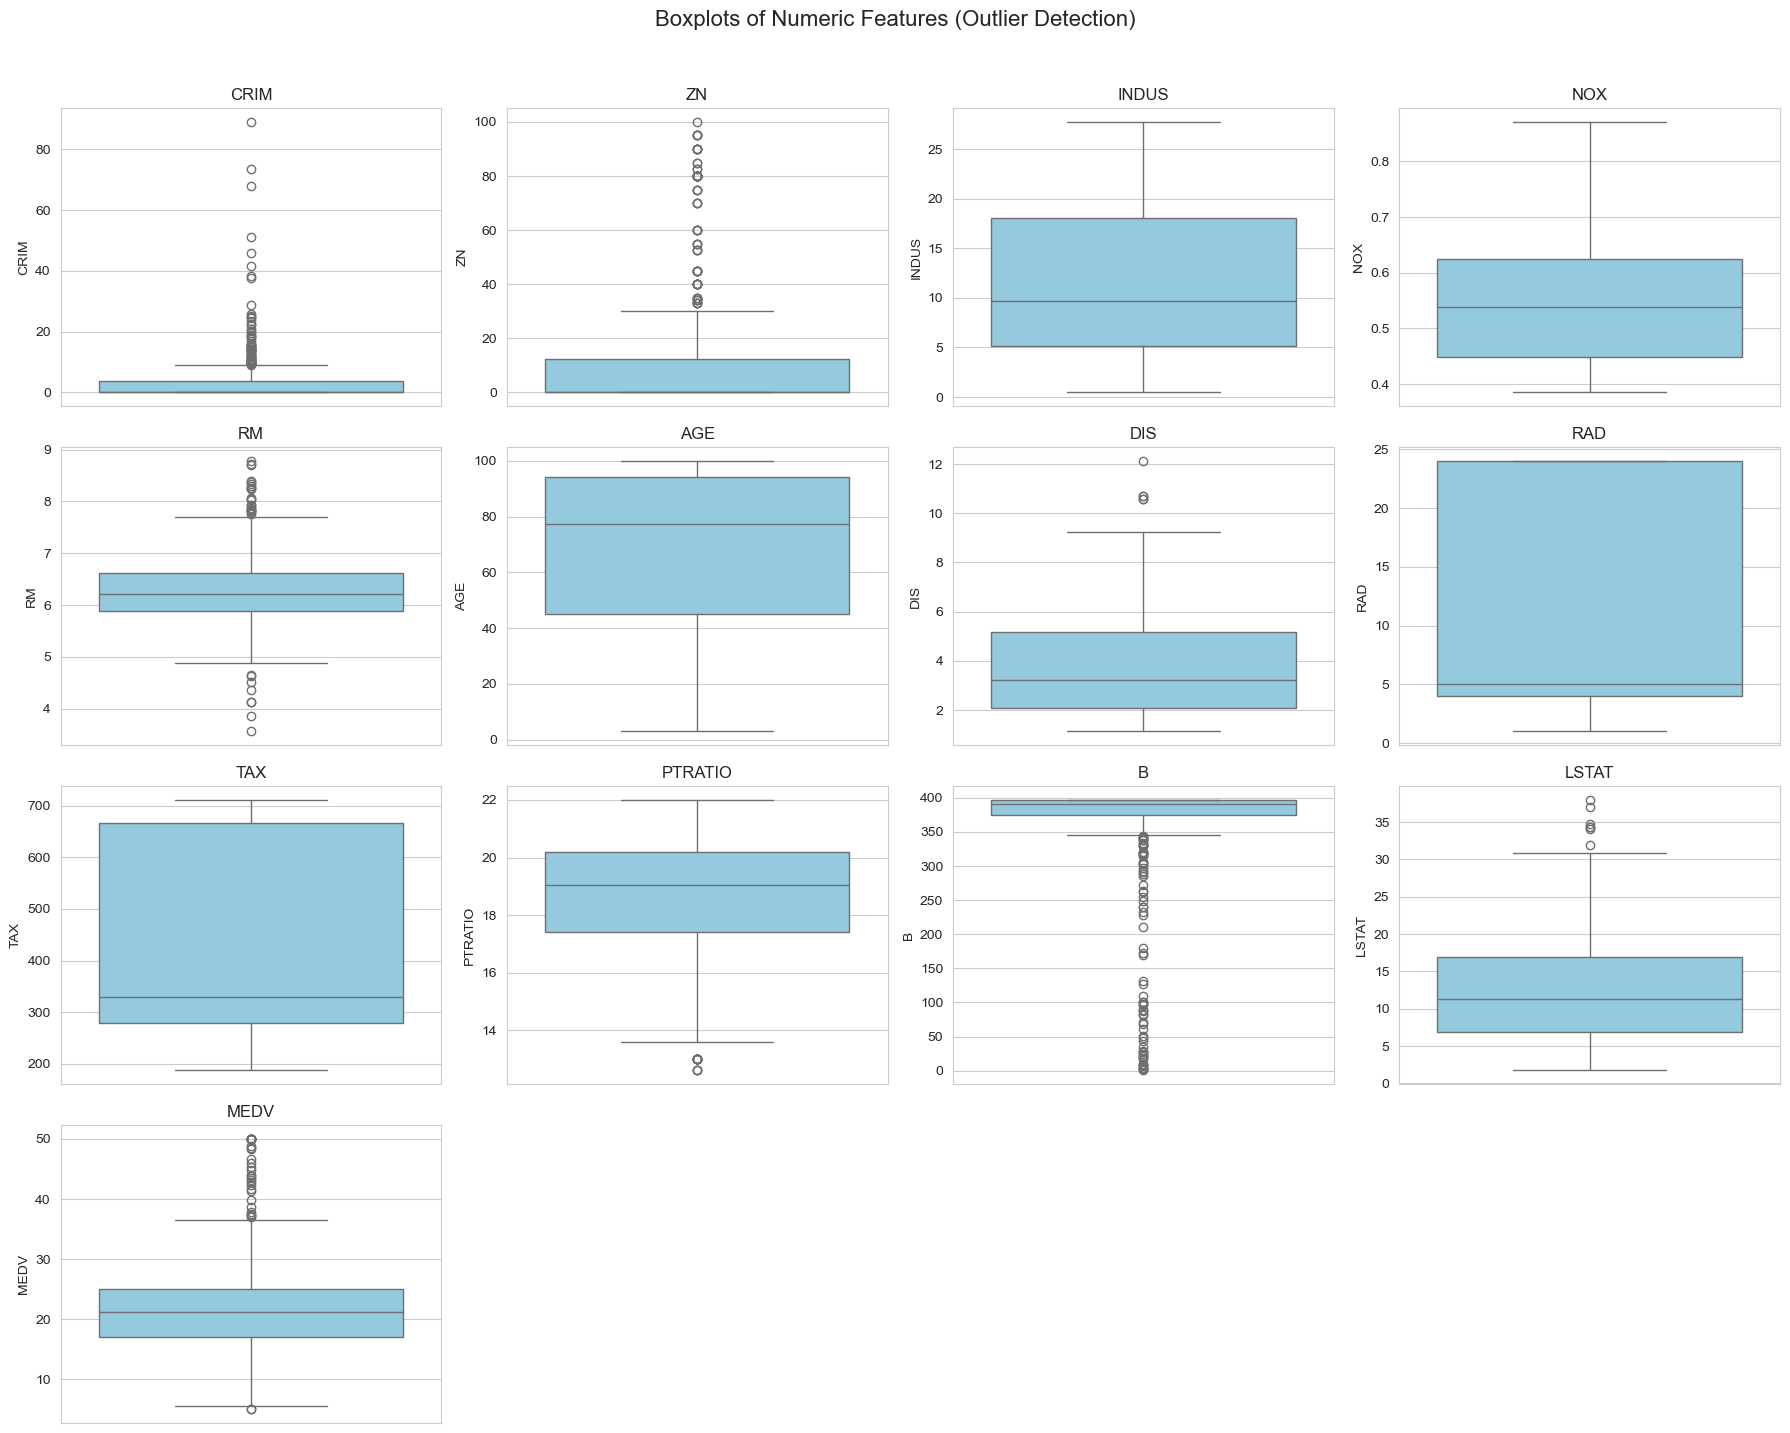

In [13]:
# Boxplots - outlier detection
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_df.columns):
    sns.boxplot(y=numeric_df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

for j in range(len(numeric_df.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots of Numeric Features (Outlier Detection)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

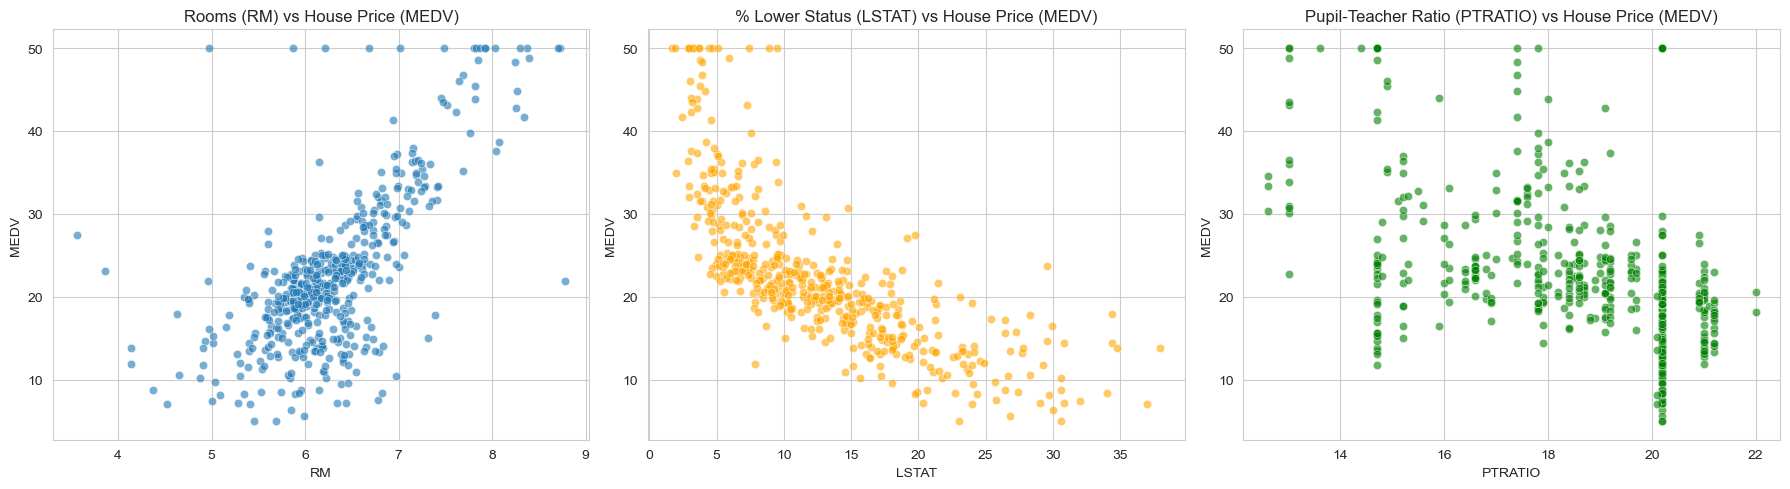

In [14]:
# Scatter plots - relationships with MEDV
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='RM', y='MEDV', ax=axes[0], alpha=0.6)
axes[0].set_title('Rooms (RM) vs House Price (MEDV)')

sns.scatterplot(data=df, x='LSTAT', y='MEDV', ax=axes[1], alpha=0.6, color='orange')
axes[1].set_title('% Lower Status (LSTAT) vs House Price (MEDV)')

sns.scatterplot(data=df, x='PTRATIO', y='MEDV', ax=axes[2], alpha=0.6, color='green')
axes[2].set_title('Pupil-Teacher Ratio (PTRATIO) vs House Price (MEDV)')

plt.tight_layout()
plt.show()

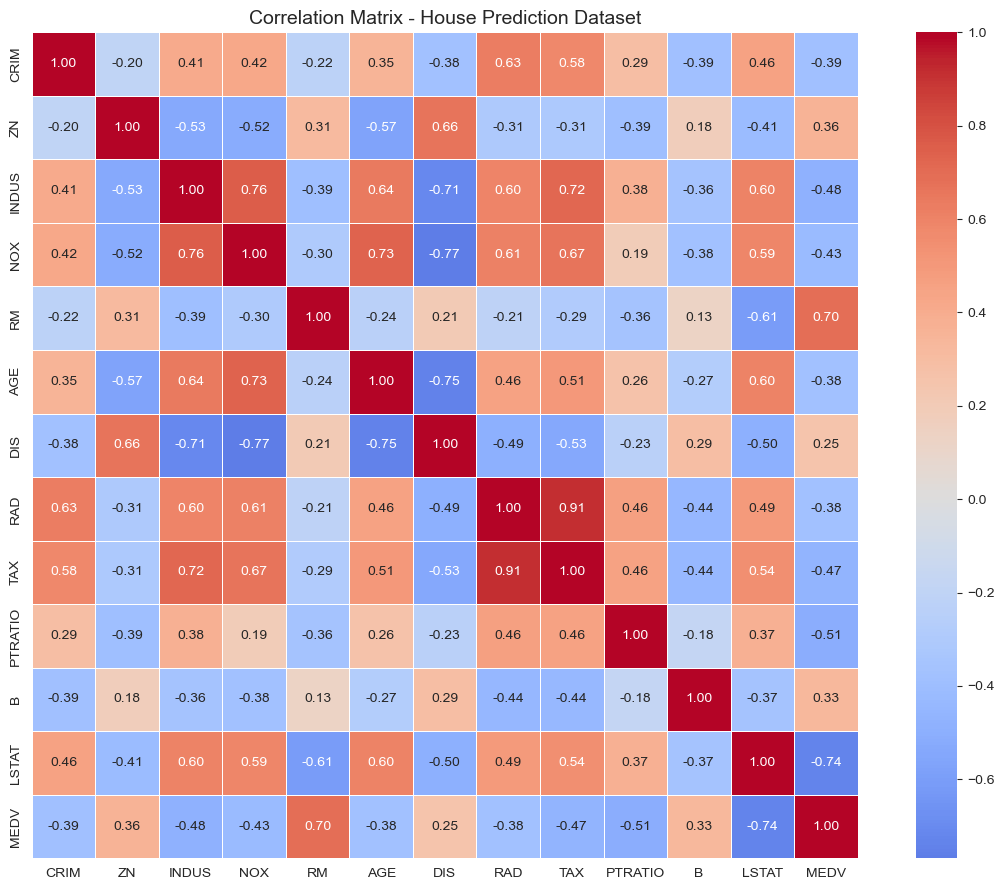

Correlation of each feature with MEDV (house price), strongest first:


LSTAT     -0.738
RM         0.695
PTRATIO   -0.508
INDUS     -0.484
TAX       -0.469
NOX       -0.427
CRIM      -0.388
RAD       -0.382
AGE       -0.377
ZN         0.360
B          0.333
DIS        0.250
Name: MEDV, dtype: float64

In [15]:
# Correlation analysis
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - House Prediction Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

medv_corr = corr_matrix['MEDV'].drop('MEDV').sort_values(key=abs, ascending=False)
print("Correlation of each feature with MEDV (house price), strongest first:")
medv_corr.round(3)

In [16]:
# Level 2 Task 1- Regression Analysis

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split into features and target
# Predicting MEDV (house price) using RM (average rooms per dwelling),
# since RM had the strongest positive correlation with price in the EDA
X = df[['RM']]
y = df['MEDV']

In [18]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")


Training set: 404 rows
Test set: 102 rows


In [19]:
# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [20]:
# Interpret coefficients and evaluate the model
print(f"\nCoefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"\nInterpretation: each additional room is associated with an increase")
print(f"of about ${model.coef_[0]*1000:.0f} in median home value.")

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"\nR-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")


Coefficient (slope): 9.3483
Intercept: -36.2463

Interpretation: each additional room is associated with an increase
of about $9348 in median home value.

R-squared: 0.3708
Mean Squared Error: 46.1448


In [21]:
# Level 2 Task 3- Clustering Analysis (K-Means)

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [23]:
# Standardize the dataset (exclude MEDV — clustering on the predictors)
df['CHAS'] = df['CHAS'].map({'No': 0, 'Yes': 1})

features = df.drop(columns=['MEDV'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

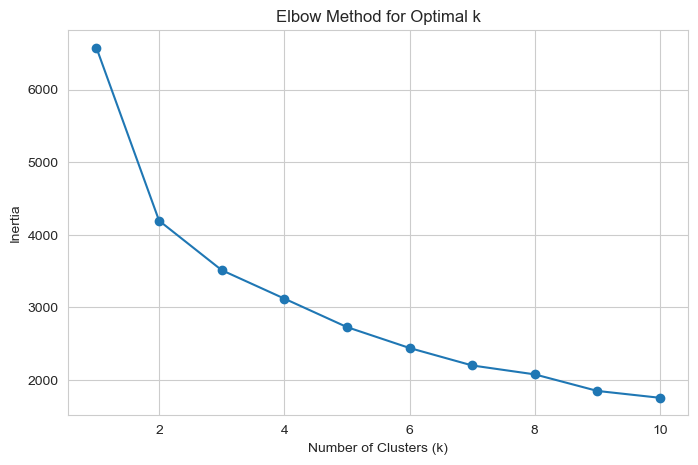

In [24]:
# Elbow method to find optimal number of clusters
inertia = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [25]:
# Apply K-Means with the chosen k (elbow bends around k=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)
df['Cluster'] = clusters

print("Number of neighborhoods per cluster:")
print(df['Cluster'].value_counts())

Number of neighborhoods per cluster:
Cluster
0    243
2    163
1    100
Name: count, dtype: int64


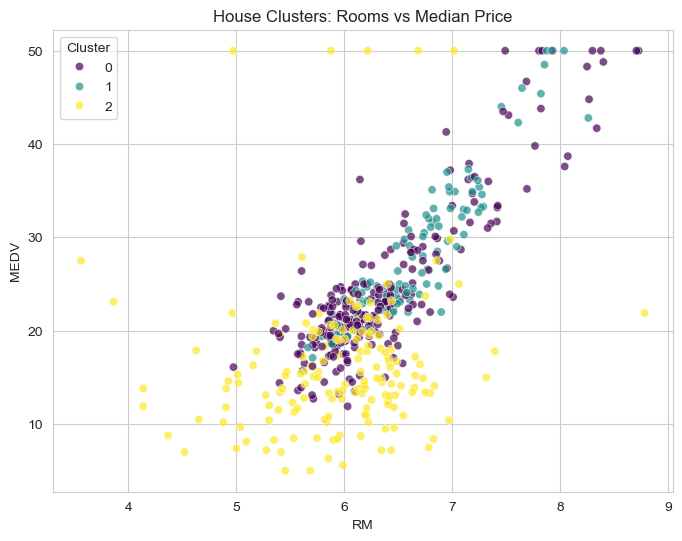

In [26]:
# Visualize clusters using a 2D scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='RM', y='MEDV', hue='Cluster', palette='viridis', alpha=0.7)
plt.title('House Clusters: Rooms vs Median Price')
plt.show()

In [27]:
# Quick look at what distinguishes each cluster
print("\nAverage feature values per cluster:")
print(df.groupby('Cluster')[['CRIM', 'RM', 'LSTAT', 'MEDV']].mean().round(2))


Average feature values per cluster:
          CRIM    RM  LSTAT   MEDV
Cluster                           
0         0.39  6.35  11.04  24.31
1         0.07  6.67   6.37  28.48
2        10.60  5.96  18.91  16.23


In [28]:
#Level 3 Task 1- Predictive Modeling (Classification)

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [30]:
# Create a categorical target
# MEDV is continuous, so we bin it into 3 price tiers using tertiles
df['PriceCategory'] = pd.qcut(df['MEDV'], q=3, labels=['Low', 'Medium', 'High'])
print("Price category distribution:")
print(df['PriceCategory'].value_counts())

Price category distribution:
PriceCategory
Medium    171
Low       169
High      166
Name: count, dtype: int64


In [31]:
# Preprocess - features/target split, scaling
X = df.drop(columns=['MEDV', 'PriceCategory'])
y = df['PriceCategory']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# Train and test multiple classification models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = [acc, prec, rec, f1]

    print(f"\n{name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy:  0.7549
Precision: 0.7631
Recall:    0.7549
F1-score:  0.7557
              precision    recall  f1-score   support

        High       0.78      0.85      0.81        33
         Low       0.86      0.71      0.77        34
      Medium       0.66      0.71      0.68        35

    accuracy                           0.75       102
   macro avg       0.76      0.76      0.76       102
weighted avg       0.76      0.75      0.76       102


Decision Tree
Accuracy:  0.7157
Precision: 0.7158
Recall:    0.7157
F1-score:  0.7156
              precision    recall  f1-score   support

        High       0.78      0.76      0.77        33
         Low       0.77      0.79      0.78        34
      Medium       0.60      0.60      0.60        35

    accuracy                           0.72       102
   macro avg       0.72      0.72      0.72       102
weighted avg       0.72      0.72      0.72       102


Random Forest
Accuracy:  0.8333
Precision: 0.8477
Recall:

In [35]:
# Hyperparameter tuning with grid search (on the best-performing model type)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("\nBest parameters found:", grid.best_params_)
print("Best cross-validation accuracy:", grid.best_score_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
print("\nTuned Random Forest test accuracy:", accuracy_score(y_test, y_pred_best))


Best parameters found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation accuracy: 0.8218209876543211

Tuned Random Forest test accuracy: 0.8333333333333334


In [36]:
# Compare all models side by side
comparison = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-score']).T
print("\nModel comparison:")
print(comparison.round(4))


Model comparison:
                     Accuracy  Precision  Recall  F1-score
Logistic Regression    0.7549     0.7631  0.7549    0.7557
Decision Tree          0.7157     0.7158  0.7157    0.7156
Random Forest          0.8333     0.8477  0.8333    0.8362
